<a href="https://colab.research.google.com/github/ke-wen/FYP/blob/main/Analytical%20Testing/property_prices_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Note: This document is for testing only and may differ from the final code of the project. Please refer to the actual code in Django.

# Exploratory analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/MyDrive/FYP_ML")
!pwd

/content/drive/MyDrive/FYP_ML


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/FYP_ML/data/Propertysale.csv')
df.head()

,id,title,ecode,Property_Type,price,publish_date,bedrooms,bathrooms,propertySize,county,is_active
0,6059871,"47 Templemore Avenue, Rathgar, Rathgar, Dublin...",D06,Terrace,1175000.0,2025-03-22 16:42:21,4.0,2.0,131 m²,Dublin 6,1
1,6059854,"Dooega East, Achill, Co. Mayo, F28W9R2",NaN,Detached,275000.0,2025-03-22 16:04:32,4.0,3.0,213 m²,Mayo,1
2,6059850,"3 Summerville Terrace Dalkey Avenue Dalkey, Da...",A96,Semi-D,1100000.0,2025-03-22 16:01:06,3.0,2.0,146 m²,Glenageary,1
3,6059824,"23 Parkside Close, D13K7C9",D13,Terrace,525000.0,2025-03-22 15:38:08,3.0,3.0,113 m²,Dublin 13,1
4,6059804,"Apartment 12, Stone Court Centre, Roscommon To...",F42,Apartment,110000.0,2025-03-22 15:03:01,1.0,1.0,NaN,Roscommon,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28605 entries, 0 to 28604
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             28605 non-null  int64  
 1   title          28603 non-null  object 
 2   ecode          24604 non-null  object 
 3   Property_Type  28596 non-null  object 
 4   price          26680 non-null  float64
 5   publish_date   28605 non-null  object 
 6   bedrooms       24863 non-null  float64
 7   bathrooms      24431 non-null  float64
 8   propertySize   22290 non-null  object 
 9   county         28605 non-null  object 
 10  is_active      28605 non-null  int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 2.4+ MB


In [ ]:
df.describe()

,id,price,bedrooms,bathrooms,is_active
count,2.860500e+04,2.668000e+04,24863.000000,24431.000000,28605.000000
mean,5.757929e+06,4.116388e+05,3.256083,2.225656,0.488446
std,6.332473e+05,4.835872e+05,1.340125,1.252210,0.499875
min,6.646000e+03,1.000000e+04,0.000000,1.000000,0.000000
25%,5.794497e+06,2.150000e+05,2.000000,1.000000,0.000000
50%,5.913394e+06,3.300000e+05,3.000000,2.000000,0.000000
75%,5.994758e+06,4.850000e+05,4.000000,3.000000,1.000000
max,6.059871e+06,3.500000e+07,41.000000,25.000000,1.000000


In [ ]:
df.shape

(28605, 11)

In [ ]:
total_null_values = df.isnull().sum().sort_values(ascending=False)
print(f"Feature-wise null values: \n{total_null_values}")

Feature-wise null values: 
propertySize     6315
bathrooms        4174
ecode            4001
bedrooms         3742
price            1925
Property_Type       9
title               2
id                  0
publish_date        0
county              0
is_active           0
dtype: int64


In [ ]:
#Convert all unit values ​​to square meters and fill empty values ​​with the average number of rooms.

import pandas as pd
import numpy as np

def convert_size(size):
    if pd.isna(size):
        return np.nan
    size = size.strip()
    if 'm²' in size:
        return float(size.replace('m²', '').strip())
    elif 'ac' in size:
        return float(size.replace('ac', '').strip()) * 4046.86
    else:
        return np.nan


df['propertySize'] = df['propertySize'].apply(convert_size)


#Calculate the average area of ​​the same number of bedrooms
bedroom_grouped_avg_size = df.groupby('bedrooms')['propertySize'].transform('mean')

#Fill rows where propertySize is empty with the average area of ​​the same number of rooms
df['propertySize'].fillna(bedroom_grouped_avg_size, inplace=True)

#If the area of ​​all properties in a bedrooms group is NaN, fill it with the overall median
median_size = df['propertySize'].median()
df['propertySize'].fillna(median_size, inplace=True)


<ipython-input-7-4a1c80285ae9>:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['propertySize'].fillna(bedroom_grouped_avg_size, inplace=True)
<ipython-input-7-4a1c80285ae9>:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [ ]:
#Fill bathrooms, bedrooms with the most frequent value
for col in ['bathrooms', 'bedrooms', 'Property_Type']:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

<ipython-input-8-dc25c6c4cf91>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
#Fill in ecode (use the ecode with the highest frequency in the same county)
if 'ecode' in df.columns and 'county' in df.columns:
    df['ecode'] = df.groupby('county')['ecode'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

In [ ]:
#Fill in price (using the average value in the same county)
if 'price' in df.columns and 'county' in df.columns:
    df['price'] = df.groupby('county')['price'].transform(lambda x: x.fillna(x.mean()))


In [ ]:
#Fill in the missing title
missing_title_mask = df['title'].isna()

#Fill in with county + bedrooms + propertySize + Property_Type
df.loc[missing_title_mask, 'title'] = df[missing_title_mask][
    ['county', 'bedrooms', 'propertySize', 'Property_Type']
].astype(str).agg(' | '.join, axis=1)


In [ ]:
total_null_values = df.isnull().sum().sort_values(ascending=False)
print(f"Feature-wise null values: \n{total_null_values}")

Feature-wise null values: 
id               0
title            0
ecode            0
Property_Type    0
price            0
publish_date     0
bedrooms         0
bathrooms        0
propertySize     0
county           0
is_active        0
dtype: int64


In [ ]:
df.describe()

,id,price,bedrooms,bathrooms,propertySize,is_active
count,2.860500e+04,2.860500e+04,28605.000000,28605.000000,2.860500e+04,28605.000000
mean,5.757929e+06,4.080136e+05,3.222583,2.046810,4.903318e+03,0.488446
std,6.332473e+05,4.687042e+05,1.252376,1.235492,4.860151e+05,0.499875
min,6.646000e+03,1.000000e+04,0.000000,1.000000,0.000000e+00,0.000000
25%,5.794497e+06,2.250000e+05,3.000000,1.000000,9.500000e+01,0.000000
50%,5.913394e+06,3.300000e+05,3.000000,2.000000,1.570000e+02,0.000000
75%,5.994758e+06,4.750000e+05,4.000000,3.000000,3.220000e+02,1.000000
max,6.059871e+06,3.500000e+07,41.000000,25.000000,8.188821e+07,1.000000


In [ ]:
#output after handling missing values
df.describe()

,id,price,bedrooms,bathrooms,propertySize,is_active
count,2.860500e+04,2.860500e+04,28605.000000,28605.000000,2.860500e+04,28605.000000
mean,5.757929e+06,4.080136e+05,3.222583,2.046810,4.903318e+03,0.488446
std,6.332473e+05,4.687042e+05,1.252376,1.235492,4.860151e+05,0.499875
min,6.646000e+03,1.000000e+04,0.000000,1.000000,0.000000e+00,0.000000
25%,5.794497e+06,2.250000e+05,3.000000,1.000000,9.500000e+01,0.000000
50%,5.913394e+06,3.300000e+05,3.000000,2.000000,1.570000e+02,0.000000
75%,5.994758e+06,4.750000e+05,4.000000,3.000000,3.220000e+02,1.000000
max,6.059871e+06,3.500000e+07,41.000000,25.000000,8.188821e+07,1.000000


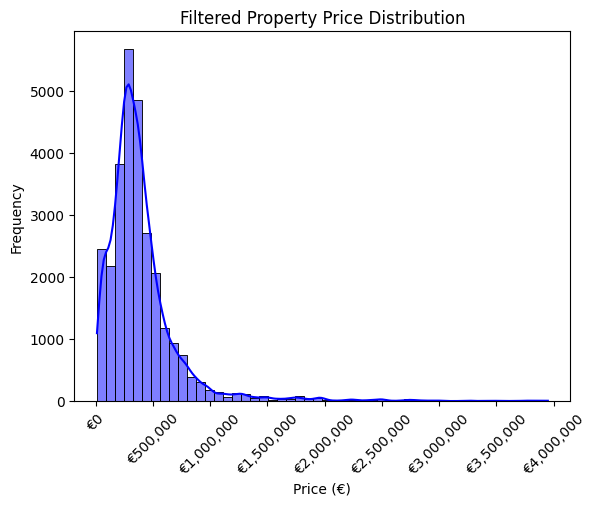

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

filtered_price_df = df[(df['price'] > 10000) & (df['price'] < 4000000)]

ax = sns.histplot(filtered_price_df['price'], bins=50, kde=True, color='blue')


ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))

plt.title('Filtered Property Price Distribution')
plt.xlabel('Price (€)')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


In [ ]:
df.head()

,id,title,ecode,Property_Type,price,publish_date,bedrooms,bathrooms,propertySize,county,is_active
0,6059871,"47 Templemore Avenue, Rathgar, Rathgar, Dublin...",D06,Terrace,1175000.0,2025-03-22 16:42:21,4.0,2.0,131.000000,Dublin 6,1
1,6059854,"Dooega East, Achill, Co. Mayo, F28W9R2",F12,Detached,275000.0,2025-03-22 16:04:32,4.0,3.0,213.000000,Mayo,1
2,6059850,"3 Summerville Terrace Dalkey Avenue Dalkey, Da...",A96,Semi-D,1100000.0,2025-03-22 16:01:06,3.0,2.0,146.000000,Glenageary,1
3,6059824,"23 Parkside Close, D13K7C9",D13,Terrace,525000.0,2025-03-22 15:38:08,3.0,3.0,113.000000,Dublin 13,1
4,6059804,"Apartment 12, Stone Court Centre, Roscommon To...",F42,Apartment,110000.0,2025-03-22 15:03:01,1.0,1.0,210.051073,Roscommon,1



Property_Type encoding map：
0 ↔ Apartment
1 ↔ Bungalow
2 ↔ Detached
3 ↔ Duplex
4 ↔ End of Terrace
5 ↔ House
6 ↔ Houses
7 ↔ Property
8 ↔ Semi-D
9 ↔ Site
10 ↔ Studio
11 ↔ Terrace
12 ↔ Townhouse

county encoding map：
0 ↔ Ashbourne
1 ↔ Balbriggan
2 ↔ Ballyboughal
3 ↔ Blackrock
4 ↔ Bray
5 ↔ Carlow
6 ↔ Cavan
7 ↔ Clare
8 ↔ Cork
9 ↔ Donegal
10 ↔ Dublin 1
11 ↔ Dublin 10
12 ↔ Dublin 11
13 ↔ Dublin 12
14 ↔ Dublin 13
15 ↔ Dublin 14
16 ↔ Dublin 15
17 ↔ Dublin 16
18 ↔ Dublin 17
19 ↔ Dublin 18
20 ↔ Dublin 2
21 ↔ Dublin 20
22 ↔ Dublin 22
23 ↔ Dublin 24
24 ↔ Dublin 3
25 ↔ Dublin 4
26 ↔ Dublin 5
27 ↔ Dublin 6
28 ↔ Dublin 7
29 ↔ Dublin 8
30 ↔ Dublin 9
31 ↔ Dunboyne
32 ↔ Dunshaughlin
33 ↔ Galway
34 ↔ Garristown
35 ↔ Glenageary
36 ↔ Kerry
37 ↔ Kildare
38 ↔ Kilkenny
39 ↔ Laois
40 ↔ Leitrim
41 ↔ Limerick
42 ↔ Longford
43 ↔ Louth
44 ↔ Lucan
45 ↔ Lusk
46 ↔ Malahide
47 ↔ Mayo
48 ↔ Meath
49 ↔ Monaghan
50 ↔ Offaly
51 ↔ Roscommon
52 ↔ Rush
53 ↔ Skerries
54 ↔ Sligo
55 ↔ Swords
56 ↔ Tipperary
57 ↔ Unknown
58 ↔ Wate

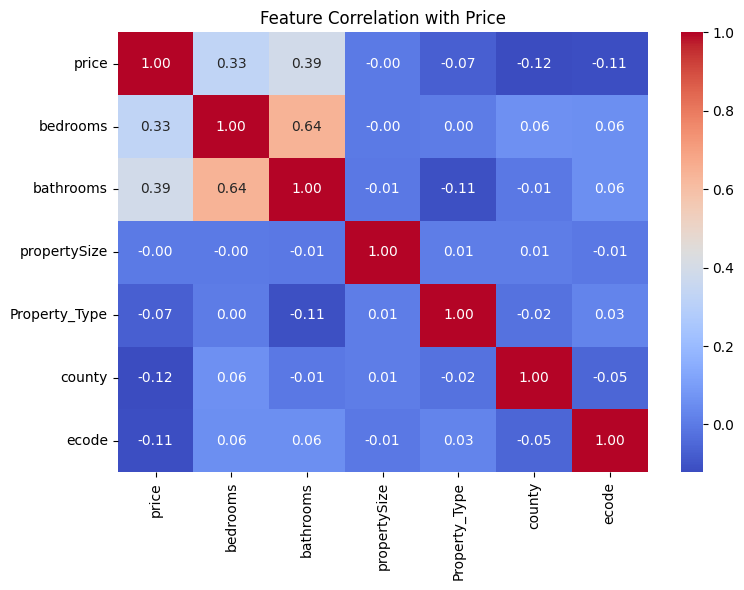

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables and store the encoders
label_encoders = {}
df_encoded = df.copy()
categorical_cols = ['Property_Type', 'county', 'ecode']

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Display mapping of encoded values for each categorical column
for col in categorical_cols:
    print(f"\n{col} encoding map：")
    for i, val in enumerate(label_encoders[col].classes_):
        print(f"{i} ↔ {val}")

# Select features for correlation analysis
selected_features = ['price', 'bedrooms', 'bathrooms', 'propertySize'] + categorical_cols
corr_matrix = df_encoded[selected_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation with Price")
plt.tight_layout()
plt.show()


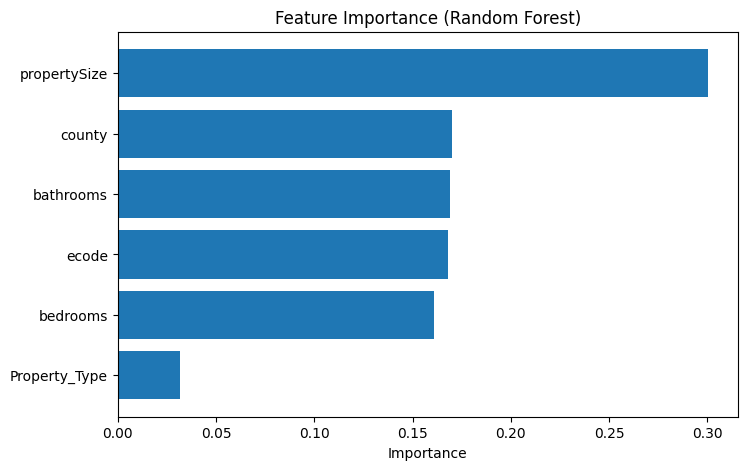

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# Select features and target
features = ['bedrooms', 'bathrooms', 'propertySize', 'Property_Type', 'county', 'ecode']
X = df_encoded[features]
y = df_encoded['price']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train random forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()


# Tryed some machine learning methods

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Feature and target setup
features = ['bedrooms', 'bathrooms', 'propertySize', 'Property_Type', 'county', 'ecode']
X = df_encoded[features]
y = df_encoded['price']

# Split train/test to avoid overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Recursive Feature Elimination with Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
rfe = RFE(estimator=model, n_features_to_select=3)
rfe.fit(X_train, y_train)

# Output selected features
selected_features_rfe = X.columns[rfe.support_]
print("Selected features by RFE + RandomForest:")
print(selected_features_rfe)


Selected features by RFE + RandomForest:
Index(['bathrooms', 'propertySize', 'ecode'], dtype='object')


<ipython-input-20-e8a59f7d5679>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[num_cols] = scaler.fit_transform(X[num_cols])


Model Evaluation Results:
MAE:  100502.14
RMSE: 241677.14
R²:   0.6008


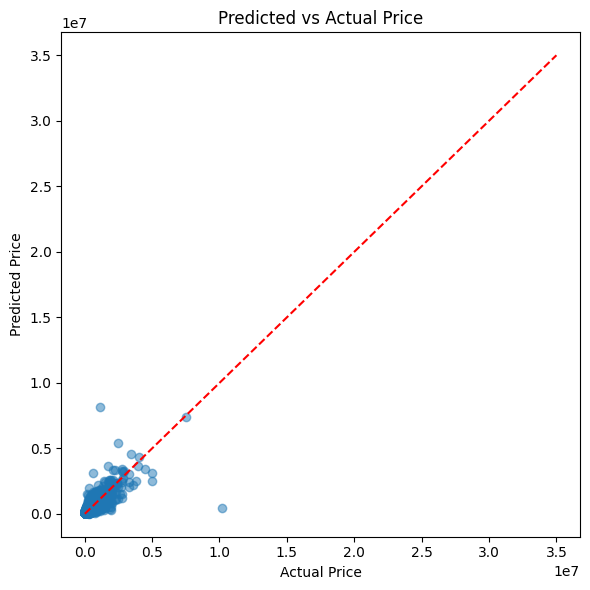

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select features (exclude 'id', 'title')
features = ['bedrooms', 'bathrooms', 'propertySize', 'Property_Type', 'county', 'ecode']
X = df_encoded[features]
y = df_encoded['price']

# Scale numeric features (optional for tree models, but included for consistency)
num_cols = ['bedrooms', 'bathrooms', 'propertySize']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# Optional: Visualize predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Price")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

#Convert publish_date to numeric (days since min date)
df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
df_encoded['publish_day'] = (df_encoded['publish_date'] - df_encoded['publish_date'].min()).dt.days

#Select features
features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'publish_day'
]
X = df_encoded[features]
y = df_encoded['price']

#Scale numeric features
num_cols = ['bedrooms', 'bathrooms', 'propertySize', 'publish_day']
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])

#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42)

#Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Evaluate model
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

#Predict price for a sample future date
future_date = pd.Timestamp("2025-04-20")
future_day = (future_date - df_encoded['publish_date'].min()).days

# Use most common encoded values as example
property_type_encoded = df_encoded['Property_Type'].mode()[0]
county_encoded = df_encoded['county'].mode()[0]
ecode_encoded = df_encoded['ecode'].mode()[0]

# Construct future sample input
sample = {
    'bedrooms': 3,
    'bathrooms': 2,
    'propertySize': 100,
    'Property_Type': property_type_encoded,
    'county': county_encoded,
    'ecode': ecode_encoded,
    'publish_day': future_day
}

# Predict using the trained model
X_future = pd.DataFrame([sample])
X_future[num_cols] = scaler.transform(X_future[num_cols])
predicted_price = model.predict(X_future)[0]

print(f"Predicted price on {future_date.date()}: €{predicted_price:,.2f}")


MAE: 101959.76463250686
R²: 0.6246826891998509
Predicted price on 2025-04-20: €363,005.84


In [ ]:
#reduce outliner with CLIP

# Cap price at 98th percentile
max_price = df_encoded['price'].quantile(0.98)
df_encoded['price'] = df_encoded['price'].clip(upper=max_price)

#Create publish_day feature
df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
df_encoded['publish_day'] = (df_encoded['publish_date'] - df_encoded['publish_date'].min()).dt.days

#Feature setup
features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'publish_day'
]
X = df_encoded[features]
y = df_encoded['price']

#Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['bedrooms', 'bathrooms', 'propertySize', 'publish_day']
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])

#Train model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Predict & evaluate
y_pred = model.predict(X_test)
print(" CLIP version:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


 CLIP version:
MAE: 87835.6290643117
R²: 0.7476266675999576


In [ ]:
#reduce outliner with log


#Apply log transform to price
df_encoded['log_price'] = np.log1p(df_encoded['price'])

#Create publish_day feature
df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
df_encoded['publish_day'] = (df_encoded['publish_date'] - df_encoded['publish_date'].min()).dt.days

#Feature setup
features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'publish_day'
]
X = df_encoded[features]
y = df_encoded['log_price']  # log target here!

# Scaling
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])

#Train model
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Predict log values and reverse
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)       # reverse log1p
y_test_real = np.expm1(y_test)      # reverse for comparison

print("LOG version:")
print("MAE:", mean_absolute_error(y_test_real, y_pred))
print("R²:", r2_score(y_test_real, y_pred))


LOG version:
MAE: 86472.91983383836
R²: 0.7345026507740262


In [ ]:
pip install xgboost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Convert publish_date to numeric days
df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
df_encoded['publish_day'] = (df_encoded['publish_date'] - df_encoded['publish_date'].min()).dt.days

# Feature list
features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'publish_day'
]
num_cols = ['bedrooms', 'bathrooms', 'propertySize', 'publish_day']

In [ ]:
# Clipped
# Clip top 2% high prices
max_price = df_encoded['price'].quantile(0.98)
df_encoded['price_clipped'] = df_encoded['price'].clip(upper=max_price)

# Prepare X and y
X = df_encoded[features]
y = df_encoded['price_clipped']

# Scale numeric columns
X_scaled = X.copy()
scaler = StandardScaler()
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42)

# Train XGBoost
xgb_model_clip = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model_clip.fit(X_train, y_train)

# Predict & evaluate
y_pred_clip = xgb_model_clip.predict(X_test)
print("XGBoost (Clipped):")
print("MAE:", mean_absolute_error(y_test, y_pred_clip))
print("R²:", r2_score(y_test, y_pred_clip))


XGBoost (Clipped):
MAE: 87248.66797843926
R²: 0.7602812721194886


In [ ]:
#log
df_encoded['log_price'] = np.log1p(df_encoded['price'])

# Prepare X and y
X = df_encoded[features]
y = df_encoded['log_price']

# Scale numeric columns
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42)

# Train XGBoost
xgb_model_log = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model_log.fit(X_train, y_train)

# Predict & evaluate (reverse log1p)
y_pred_log = xgb_model_log.predict(X_test)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

print("XGBoost (Log):")
print("MAE:", mean_absolute_error(y_test_real, y_pred_real))
print("R²:", r2_score(y_test_real, y_pred_real))

XGBoost (Log):
MAE: 85474.4942259189
R²: 0.7464515174371379


# Further implementation of machine learning

Detected price trend: 0.000276 log units per day
Estimated annual price change: 10.61%
Training data time range: 2022-12-02 14:57:21 to 2025-02-17 15:44:36
Testing data time range: 2025-02-17 15:45:32 to 2025-03-22 17:13:23
Model Evaluation Results (original price scale):
MAE: 105035.33
R²: 0.7091

Future Price Predictions for Sample Property:
Date: 2025-04-23, Predicted Price: €288,927.52
Date: 2025-05-23, Predicted Price: €291,331.25
Date: 2025-06-23, Predicted Price: €293,836.11


<ipython-input-28-8f26781c7091>:128: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates_3y = pd.date_range(start=today, end=today + pd.DateOffset(years=3), freq='3M')


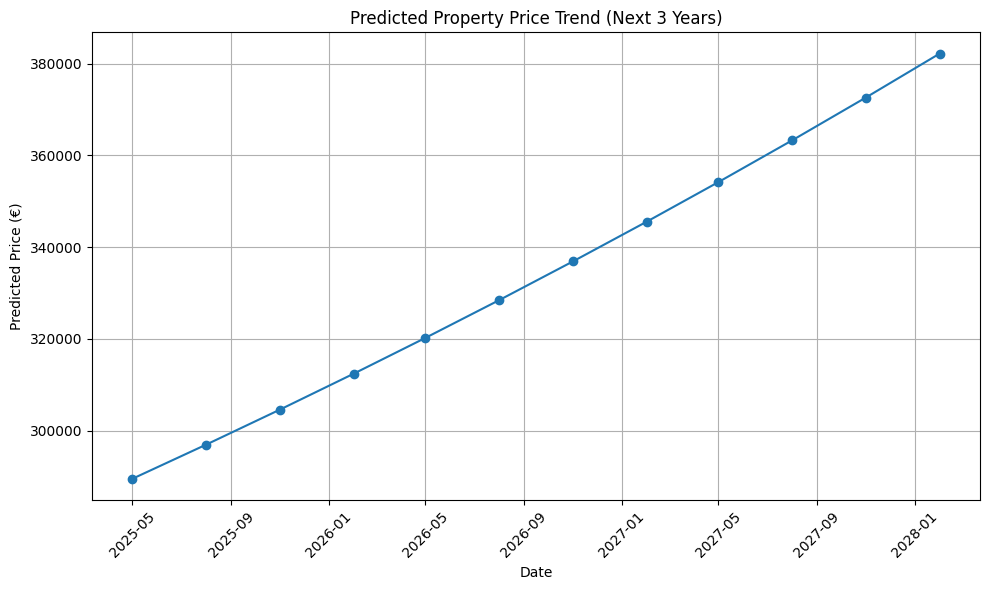

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Apply log transformation to price
df_encoded['log_price'] = np.log1p(df_encoded['price'])  # log1p to handle zeros safely

# Process the date - simpler approach without seasonality components
df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
min_date = df_encoded['publish_date'].min()

# Only extract days since min date as time feature
df_encoded['days_since_min'] = (df_encoded['publish_date'] - min_date).dt.days

# Calculate the time trend of log prices
yearly_avg_log_prices = df_encoded.groupby(
    df_encoded['publish_date'].dt.year
)['log_price'].mean().reset_index()

yearly_avg_log_prices['year_date'] = pd.to_datetime(
    yearly_avg_log_prices['publish_date'].astype(str) + '-01-01'
)
yearly_avg_log_prices = yearly_avg_log_prices.sort_values('year_date')

# Calculate the log price trend coefficient
from sklearn.linear_model import LinearRegression
days_array = (yearly_avg_log_prices['year_date'] - min_date).dt.days.values.reshape(-1, 1)
log_price_array = yearly_avg_log_prices['log_price'].values
log_trend_model = LinearRegression()
log_trend_model.fit(days_array, log_price_array)
log_price_trend_coef = log_trend_model.coef_[0]

# Calculate approximate percentage change per year (using properties of logarithms)
annual_pct_change = (np.exp(log_price_trend_coef * 365) - 1) * 100
print(f"Detected price trend: {log_price_trend_coef:.6f} log units per day")
print(f"Estimated annual price change: {annual_pct_change:.2f}%")

# Select features for the model - simpler set without seasonal components
features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'days_since_min'
]
X = df_encoded[features]
y = df_encoded['log_price']

# Create a time-based train-test split
df_encoded = df_encoded.sort_values('publish_date')
train_size = 0.8
train_idx = int(len(df_encoded) * train_size)

X_train = X.iloc[:train_idx]
X_test = X.iloc[train_idx:]
y_train = y.iloc[:train_idx]
y_test = y.iloc[train_idx:]

print(f"Training data time range: {df_encoded['publish_date'].iloc[0]} to {df_encoded['publish_date'].iloc[train_idx-1]}")
print(f"Testing data time range: {df_encoded['publish_date'].iloc[train_idx]} to {df_encoded['publish_date'].iloc[-1]}")

# Scale numeric features
num_cols = ['bedrooms', 'bathrooms', 'propertySize', 'days_since_min']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate on test data
y_pred_log = model.predict(X_test_scaled)

# Convert back to original scale for evaluation
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

print("Model Evaluation Results (original price scale):")
print(f"MAE: {mean_absolute_error(y_test_orig, y_pred_orig):.2f}")
print(f"R²: {r2_score(y_test_orig, y_pred_orig):.4f}")

# Function to predict future prices with log transformation
def predict_future_price(future_date, property_features):
    future_date = pd.to_datetime(future_date)
    X_future = pd.DataFrame([property_features])
    X_future['days_since_min'] = (future_date - min_date).days
    X_future = X_future[features]
    X_future[num_cols] = scaler.transform(X_future[num_cols])
    base_log_prediction = model.predict(X_future)[0]
    max_train_date = df_encoded['publish_date'].iloc[train_idx-1]
    days_beyond_training = max(0, (future_date - max_train_date).days)
    log_trend_adjustment = days_beyond_training * log_price_trend_coef
    adjusted_log_prediction = base_log_prediction + log_trend_adjustment
    return np.expm1(adjusted_log_prediction)


# Test the function with a future date
sample_property = {
    'bedrooms': 3,
    'bathrooms': 2,
    'propertySize': 100,
    'Property_Type': 2,
    'county': 47,
    'ecode': 56,
}

# Predict for 3 month
today = pd.Timestamp.now()
future_dates = [
    today + pd.DateOffset(months=0),
    today + pd.DateOffset(months=1),
    today + pd.DateOffset(months=2)
]

print("\nFuture Price Predictions for Sample Property:")
for date in future_dates:
    predicted_price = predict_future_price(date, sample_property)
    print(f"Date: {date.date()}, Predicted Price: €{predicted_price:,.2f}")

# Plot price trend over next 3 years
future_dates_3y = pd.date_range(start=today, end=today + pd.DateOffset(years=3), freq='3M')
future_prices = []

for date in future_dates_3y:
    price = predict_future_price(date, sample_property)
    future_prices.append(price)

plt.figure(figsize=(10, 6))
plt.plot(future_dates_3y, future_prices, marker='o')
plt.title("Predicted Property Price Trend (Next 3 Years)")
plt.xlabel("Date")
plt.ylabel("Predicted Price (€)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Detected price trend: 0.000419 log units per day
Estimated annual price change: 16.54%
Training data time range: 2022-12-02 14:57:21 to 2025-02-17 15:44:36
Testing data time range: 2025-02-17 15:45:32 to 2025-03-22 17:13:23
Model Evaluation Results (original price scale):
MAE: 86871.55
R²: 0.7229

Future Price Predictions for Sample Property:
Date: 2025-04-23, Predicted Price: €268,109.01
Date: 2025-05-23, Predicted Price: €267,357.24
Date: 2025-06-23, Predicted Price: €275,428.89


<ipython-input-29-20d85d45faef>:141: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates_3y = pd.date_range(start=today, end=today + pd.DateOffset(years=3), freq='3M')


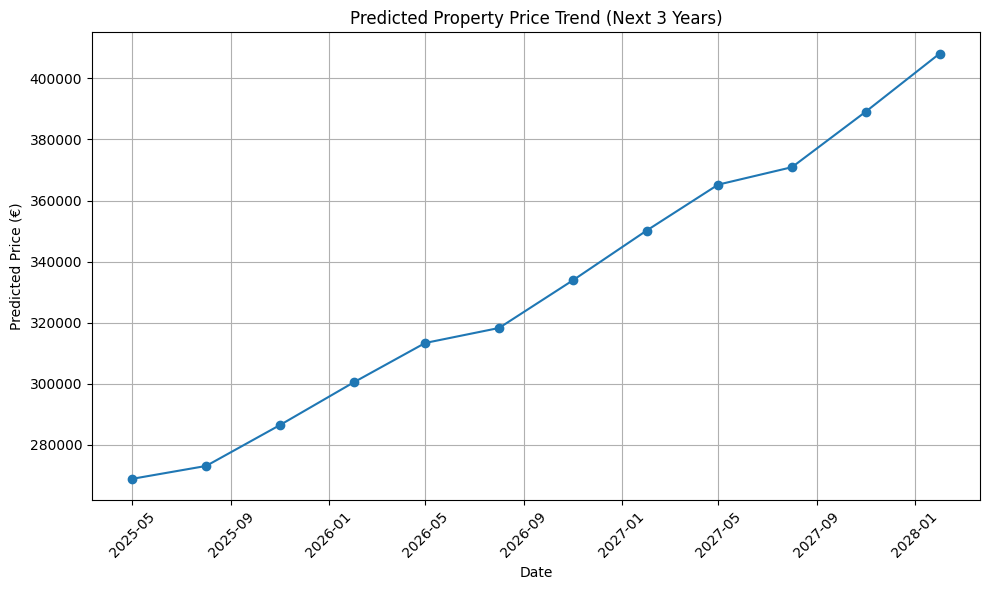

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Apply log transformation to price
df_encoded['log_price'] = np.log1p(df_encoded['price'])

df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
min_date = df_encoded['publish_date'].min()

# Extract meaningful time components
df_encoded['publish_day'] = (df_encoded['publish_date'] - min_date).dt.days
df_encoded['publish_year'] = df_encoded['publish_date'].dt.year
df_encoded['publish_month'] = df_encoded['publish_date'].dt.month
df_encoded['publish_quarter'] = df_encoded['publish_date'].dt.quarter

# Add cyclical features for month (to capture seasonality)
df_encoded['month_sin'] = np.sin(2 * np.pi * df_encoded['publish_month']/12)
df_encoded['month_cos'] = np.cos(2 * np.pi * df_encoded['publish_month']/12)

# Calculate the time trend of log prices
monthly_avg_log_prices = df_encoded.groupby(
    [df_encoded['publish_year'], df_encoded['publish_month']]
)['log_price'].mean().reset_index()

monthly_avg_log_prices['month_date'] = pd.to_datetime(
    monthly_avg_log_prices['publish_year'].astype(str) + '-' +
    monthly_avg_log_prices['publish_month'].astype(str) + '-01'
)
monthly_avg_log_prices = monthly_avg_log_prices.sort_values('month_date')

# Calculate the log price trend coefficient
from sklearn.linear_model import LinearRegression
days_array = (monthly_avg_log_prices['month_date'] - min_date).dt.days.values.reshape(-1, 1)
log_price_array = monthly_avg_log_prices['log_price'].values
log_trend_model = LinearRegression()
log_trend_model.fit(days_array, log_price_array)
log_price_trend_coef = log_trend_model.coef_[0]

# Calculate approximate percentage change per year
annual_pct_change = (np.exp(log_price_trend_coef * 365) - 1) * 100
print(f"Detected price trend: {log_price_trend_coef:.6f} log units per day")
print(f"Estimated annual price change: {annual_pct_change:.2f}%")

# Select features for the model
features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'publish_day', 'publish_month', 'publish_quarter',
    'month_sin', 'month_cos'
]
X = df_encoded[features]
y = df_encoded['log_price']

# Create a time-based train-test split
df_encoded = df_encoded.sort_values('publish_date')
train_size = 0.8
train_idx = int(len(df_encoded) * train_size)

X_train = X.iloc[:train_idx]
X_test = X.iloc[train_idx:]
y_train = y.iloc[:train_idx]
y_test = y.iloc[train_idx:]

print(f"Training data time range: {df_encoded['publish_date'].iloc[0]} to {df_encoded['publish_date'].iloc[train_idx-1]}")
print(f"Testing data time range: {df_encoded['publish_date'].iloc[train_idx]} to {df_encoded['publish_date'].iloc[-1]}")

# Scale numeric features
num_cols = ['bedrooms', 'bathrooms', 'propertySize', 'publish_day', 'publish_month', 'publish_quarter', 'month_sin', 'month_cos']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate on test data
y_pred_log = model.predict(X_test_scaled)

# Convert back to original scale for evaluation
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

print("Model Evaluation Results (original price scale):")
print(f"MAE: {mean_absolute_error(y_test_orig, y_pred_orig):.2f}")
print(f"R²: {r2_score(y_test_orig, y_pred_orig):.4f}")

# Function to predict future prices with log transformation
def predict_future_price(future_date, property_features):
    # Convert to datetime
    future_date = pd.to_datetime(future_date)
    X_future = pd.DataFrame([property_features])

    # Calculate time features
    X_future['publish_day'] = (future_date - min_date).days
    X_future['publish_month'] = future_date.month
    X_future['publish_quarter'] = (future_date.month - 1) // 3 + 1
    X_future['month_sin'] = np.sin(2 * np.pi * future_date.month/12)
    X_future['month_cos'] = np.cos(2 * np.pi * future_date.month/12)
    X_future = X_future[features]
    X_future[num_cols] = scaler.transform(X_future[num_cols])
    base_log_prediction = model.predict(X_future)[0]
    max_train_date = df_encoded['publish_date'].iloc[train_idx-1]
    days_beyond_training = max(0, (future_date - max_train_date).days)
    log_trend_adjustment = days_beyond_training * log_price_trend_coef
    adjusted_log_prediction = base_log_prediction + log_trend_adjustment
    return np.expm1(adjusted_log_prediction)

# Test the function with a future date
sample_property = {
    'bedrooms': 3,
    'bathrooms': 2,
    'propertySize': 100,
    'Property_Type': 2,
    'county': 47,
    'ecode': 56,
}

# Predict for 3 month
today = pd.Timestamp.now()
future_dates = [
    today + pd.DateOffset(months=0),
    today + pd.DateOffset(months=1),
    today + pd.DateOffset(months=2)
]

print("\nFuture Price Predictions for Sample Property:")
for date in future_dates:
    predicted_price = predict_future_price(date, sample_property)
    print(f"Date: {date.date()}, Predicted Price: €{predicted_price:,.2f}")

# Plot price trend over next 3 years
future_dates_3y = pd.date_range(start=today, end=today + pd.DateOffset(years=3), freq='3M')
future_prices = []

for date in future_dates_3y:
    price = predict_future_price(date, sample_property)
    future_prices.append(price)

plt.figure(figsize=(10, 6))
plt.plot(future_dates_3y, future_prices, marker='o')
plt.title("Predicted Property Price Trend (Next 3 Years)")
plt.xlabel("Date")
plt.ylabel("Predicted Price (€)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Detected price trend: 0.000290 log units per day
Estimated annual price change: 11.17%
Training data time range: 2022-12-02 14:57:21 to 2025-02-17 16:12:10
Testing data time range: 2025-02-17 16:12:11 to 2025-03-22 17:13:23
XGBoost Model Evaluation Results (original price scale):
MAE: 84157.94
R²: 0.7272

Feature Importance:
bathrooms: 0.4615
bedrooms: 0.1328
propertySize: 0.1180
county: 0.1053
ecode: 0.0864
Property_Type: 0.0820
days_since_min: 0.0140

Future Price Predictions for Sample Property (XGBoost):
Date: 2025-04-23, Predicted Price: €227,992.62
Date: 2025-05-23, Predicted Price: €229,985.41
Date: 2025-07-23, Predicted Price: €234,091.31


<ipython-input-35-3ac37af12015>:165: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates_5y = pd.date_range(start=today, end=today + pd.DateOffset(years=5), freq='6M')


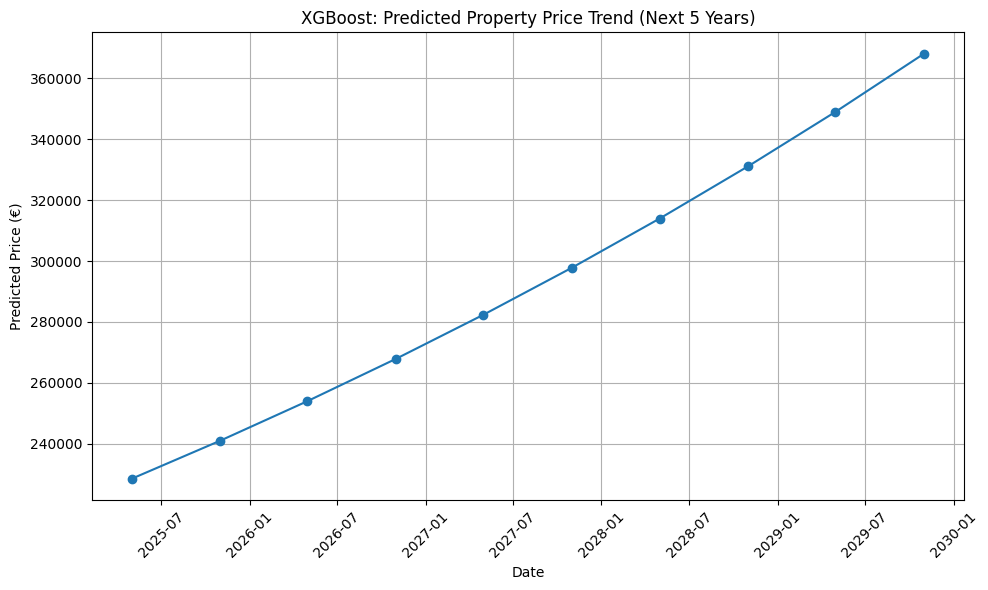

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


# Apply log transformation to price
q_low, q_high = df_encoded['price'].quantile([0.001, 0.999])
df_encoded = df_encoded[(df_encoded['price'] >= q_low) & (df_encoded['price'] <= q_high)]
df_encoded['log_price'] = np.log1p(df_encoded['price'])  # log1p to handle zeros safely

# Process the date
df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
min_date = df_encoded['publish_date'].min()

# Extract time features
df_encoded['days_since_min'] = (df_encoded['publish_date'] - min_date).dt.days
df_encoded['publish_year'] = df_encoded['publish_date'].dt.year
df_encoded['publish_month'] = df_encoded['publish_date'].dt.month

# Calculate the time trend of log prices
yearly_avg_log_prices = df_encoded.groupby(
    df_encoded['publish_date'].dt.year
)['log_price'].mean().reset_index()

yearly_avg_log_prices['year_date'] = pd.to_datetime(
    yearly_avg_log_prices['publish_date'].astype(str) + '-01-01'
)
yearly_avg_log_prices = yearly_avg_log_prices.sort_values('year_date')

# Calculate the log price trend coefficient
from sklearn.linear_model import LinearRegression
days_array = (yearly_avg_log_prices['year_date'] - min_date).dt.days.values.reshape(-1, 1)
log_price_array = yearly_avg_log_prices['log_price'].values
log_trend_model = LinearRegression()
log_trend_model.fit(days_array, log_price_array)
log_price_trend_coef = log_trend_model.coef_[0]

# Calculate approximate percentage change per year
annual_pct_change = (np.exp(log_price_trend_coef * 365) - 1) * 100
print(f"Detected price trend: {log_price_trend_coef:.6f} log units per day")
print(f"Estimated annual price change: {annual_pct_change:.2f}%")

# Select features for the model
features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'days_since_min'
]
X = df_encoded[features]
y = df_encoded['log_price']
# Create a time-based train-test split
df_encoded = df_encoded.sort_values('publish_date')
train_size = 0.8
train_idx = int(len(df_encoded) * train_size)

X_train = X.iloc[:train_idx]
X_test = X.iloc[train_idx:]
y_train = y.iloc[:train_idx]
y_test = y.iloc[train_idx:]

print(f"Training data time range: {df_encoded['publish_date'].iloc[0]} to {df_encoded['publish_date'].iloc[train_idx-1]}")
print(f"Testing data time range: {df_encoded['publish_date'].iloc[train_idx]} to {df_encoded['publish_date'].iloc[-1]}")

# Scale numeric features
num_cols = ['bedrooms', 'bathrooms', 'propertySize', 'days_since_min']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

# Evaluate on test data (log scale)
y_pred_log = xgb_model.predict(X_test_scaled)

# Convert back to original scale for evaluation
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

print("XGBoost Model Evaluation Results (original price scale):")
print(f"MAE: {mean_absolute_error(y_test_orig, y_pred_orig):.2f}")
print(f"R²: {r2_score(y_test_orig, y_pred_orig):.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
for index, row in feature_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

# Function to predict future prices with XGBoost and log transformation
def predict_future_price_xgb(future_date, property_features):
    # Convert to datetime
    future_date = pd.to_datetime(future_date)

    X_future = pd.DataFrame([property_features])

    # Calculate time features
    X_future['days_since_min'] = (future_date - min_date).days

    X_future = X_future[features]

    X_future[num_cols] = scaler.transform(X_future[num_cols])

    # Get base prediction
    base_log_prediction = xgb_model.predict(X_future)[0]

    max_train_date = df_encoded['publish_date'].iloc[train_idx-1]
    days_beyond_training = max(0, (future_date - max_train_date).days)

    # Apply log trend adjustment for dates beyond training data
    log_trend_adjustment = days_beyond_training * log_price_trend_coef

    adjusted_log_prediction = base_log_prediction + log_trend_adjustment
    return np.expm1(adjusted_log_prediction)

# Test the function with a future date
sample_property = {
    'bedrooms': 3,
    'bathrooms': 2,
    'propertySize': 100,
    'Property_Type': 2,
    'county': 47,
    'ecode': 56,
}

# Predict for 3 future dates: 6 months, 1 year, and 2 years from now
today = pd.Timestamp.now()
future_dates = [
    today + pd.DateOffset(months=0),
    today + pd.DateOffset(months=1),
    today + pd.DateOffset(months=3)
]

print("\nFuture Price Predictions for Sample Property (XGBoost):")
for date in future_dates:
    predicted_price = predict_future_price_xgb(date, sample_property)
    print(f"Date: {date.date()}, Predicted Price: €{predicted_price:,.2f}")

# Plot price trend over next 5 years
future_dates_5y = pd.date_range(start=today, end=today + pd.DateOffset(years=5), freq='6M')
future_prices = []

for date in future_dates_5y:
    price = predict_future_price_xgb(date, sample_property)
    future_prices.append(price)

plt.figure(figsize=(10, 6))
plt.plot(future_dates_5y, future_prices, marker='o')
plt.title("XGBoost: Predicted Property Price Trend (Next 5 Years)")
plt.xlabel("Date")
plt.ylabel("Predicted Price (€)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Training period: 2022-12-02 14:57:21 to 2025-02-17 15:44:36
Testing period: 2025-02-17 15:45:32 to 2025-03-22 17:13:23

Linear Regression Model Evaluation:
MAE: 173632.46
R²: -7.1991

Time trend coefficient: 0.05496334 (log units per day)
Equivalent to approximately 2062.32% price change per year

Future Price Predictions:
Date: 2025-04-23, Predicted Price: €332,066.23
Date: 2025-05-23, Predicted Price: €341,841.60
Date: 2025-07-23, Predicted Price: €362,614.63


<ipython-input-31-9071c0a8179f>:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
<ipython-input-31-9071c0a8179f>:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[num_cols] = scaler.transform(test_df[num_cols])
<ipython-input-31-9071c0a8179f>:140: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_range = pd.date_range(start=today, end=today + pd.DateOffset(years=5), freq='3M')



Feature Importance (Coefficients):
bathrooms: 0.325996
days_since_min: 0.054963
bedrooms: 0.052027
Property_Type: -0.029058
county: -0.009270
propertySize: -0.003827
ecode: -0.001494


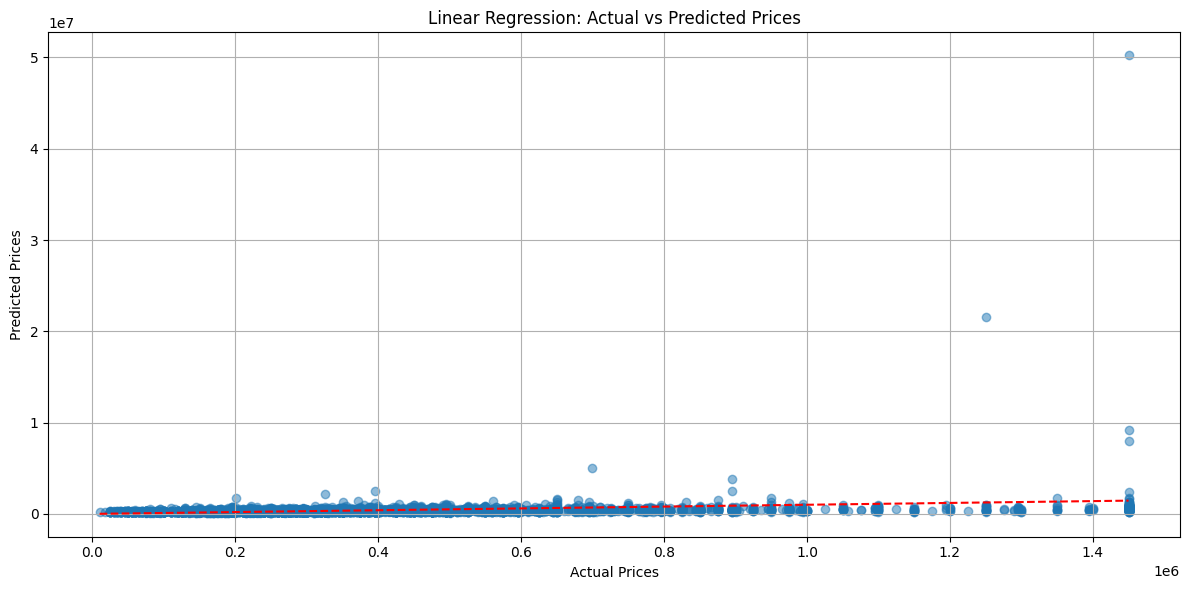

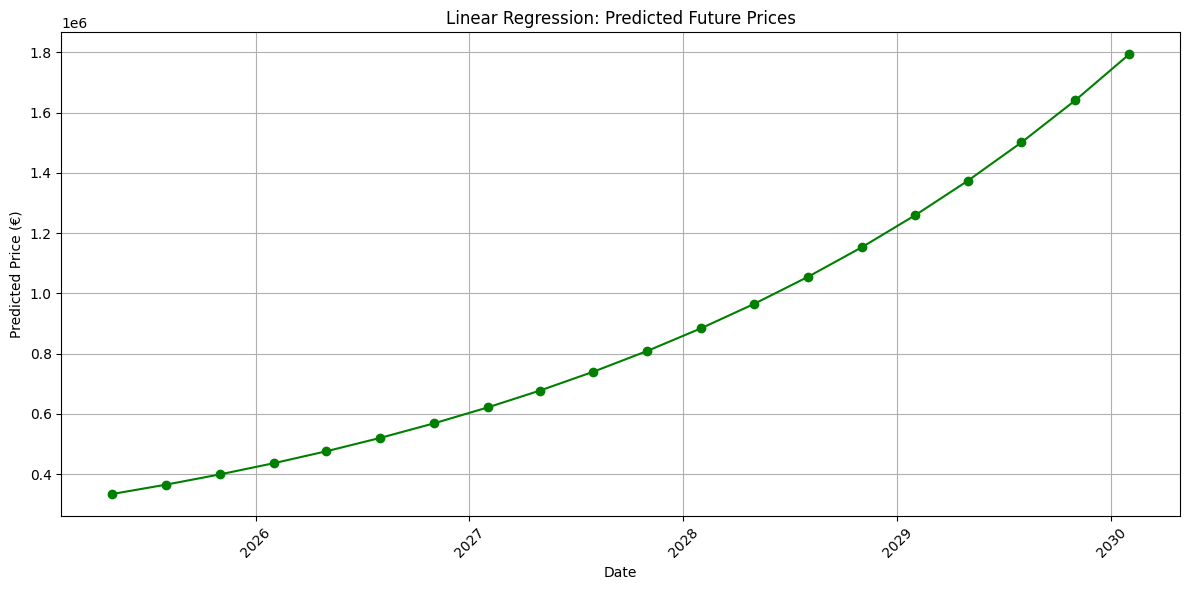

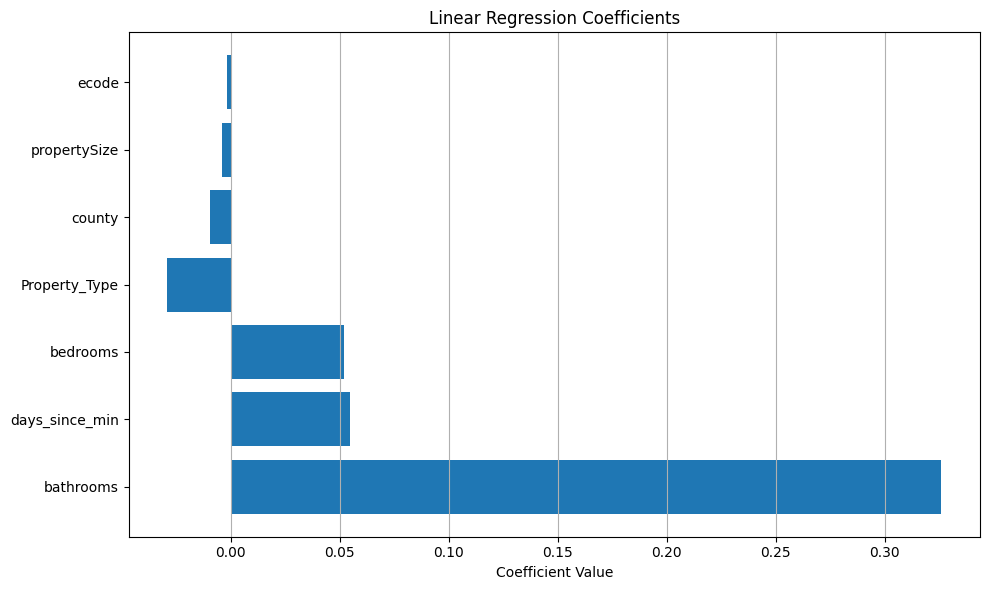

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Prepare data
df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
df_encoded = df_encoded.sort_values('publish_date')

# Apply log transformation to price
df_encoded['log_price'] = np.log1p(df_encoded['price'])

# Create time feature
min_date = df_encoded['publish_date'].min()
df_encoded['days_since_min'] = (df_encoded['publish_date'] - min_date).dt.days


features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'days_since_min'
]
model_df = df_encoded[features + ['log_price', 'publish_date']].copy()

cat_cols = ['Property_Type', 'county', 'ecode']
for col in cat_cols:
    model_df[col] = model_df[col].astype('category').cat.codes

# Time-based train-test split
train_size = 0.8
n_samples = len(model_df)
train_idx = int(n_samples * train_size)

train_df = model_df.iloc[:train_idx]
test_df = model_df.iloc[train_idx:]

print(f"Training period: {train_df['publish_date'].min()} to {train_df['publish_date'].max()}")
print(f"Testing period: {test_df['publish_date'].min()} to {test_df['publish_date'].max()}")

# Scale numeric features
num_cols = ['bedrooms', 'bathrooms', 'propertySize', 'days_since_min']
scaler = StandardScaler()
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

# Prepare train and test data
X_train = train_df[features]
y_train = train_df['log_price']
X_test = test_df[features]
y_test = test_df['log_price']

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred_log = model.predict(X_test)

# Convert back to original scale
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print("\nLinear Regression Model Evaluation:")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.5)
plt.plot([min(y_test_orig), max(y_test_orig)], [min(y_test_orig), max(y_test_orig)], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.grid(True)
plt.tight_layout()

time_coef = model.coef_[features.index('days_since_min')]
daily_trend_pct = (np.exp(time_coef) - 1) * 100
annual_trend_pct = daily_trend_pct * 365

print(f"\nTime trend coefficient: {time_coef:.8f} (log units per day)")
print(f"Equivalent to approximately {annual_trend_pct:.2f}% price change per year")

# Function to predict future prices
def predict_future_price(future_date, property_features):

    future_date = pd.to_datetime(future_date)

    pred_df = pd.DataFrame([property_features])

    pred_df['days_since_min'] = (future_date - min_date).days

    # Handle categorical features
    for col in cat_cols:
        if col in property_features:
            pred_df[col] = property_features[col]
        else:
            pred_df[col] = train_df[col].mode()[0]

    # Scale numeric features
    pred_df[num_cols] = scaler.transform(pred_df[num_cols])

    # Predict log price
    log_price = model.predict(pred_df[features])[0]

    # Convert to original scale
    return np.expm1(log_price)

# Sample property features
sample_property = {
    'bedrooms': 3,
    'bathrooms': 2,
    'propertySize': 100,
    'Property_Type': 2,
    'county': 47,
    'ecode': 56,
}

# Predict for future dates
today = pd.Timestamp.now()
future_dates = [
    today + pd.DateOffset(months=0),
    today + pd.DateOffset(months=1),
    today + pd.DateOffset(months=3)
]

print("\nFuture Price Predictions:")
for date in future_dates:
    price = predict_future_price(date, sample_property)
    print(f"Date: {date.date()}, Predicted Price: €{price:,.2f}")

# Plot future price trend
future_range = pd.date_range(start=today, end=today + pd.DateOffset(years=5), freq='3M')
future_prices = []

for date in future_range:
    price = predict_future_price(date, sample_property)
    future_prices.append(price)

plt.figure(figsize=(12, 6))
plt.plot(future_range, future_prices, 'g-', marker='o')
plt.title('Linear Regression: Predicted Future Prices')
plt.xlabel('Date')
plt.ylabel('Predicted Price (€)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Feature importance
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})
coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("\nFeature Importance (Coefficients):")
for i, row in coefficients.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.6f}")

# Plot coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients')
plt.grid(True, axis='x')
plt.tight_layout()

plt.show()

Detected trend: 0.000276 log units/day
Annual price change: 10.61%
Training: 2022-12-02 14:57:21 to 2025-02-17 15:44:36
Testing: 2025-02-17 15:45:32 to 2025-03-22 17:13:23

Decision Tree Results:
MAE: 100960.83
R²: 0.6574

Predictions for sample property:
Date: 2025-04-23, Price: €291,068.04
Date: 2025-05-23, Price: €293,489.58
Date: 2025-06-23, Price: €296,013.00
Date: 2025-07-23, Price: €298,475.68


<ipython-input-32-85d8d4cfc159>:129: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates_5y = pd.date_range(start=today, end=today + pd.DateOffset(years=5), freq='3M')


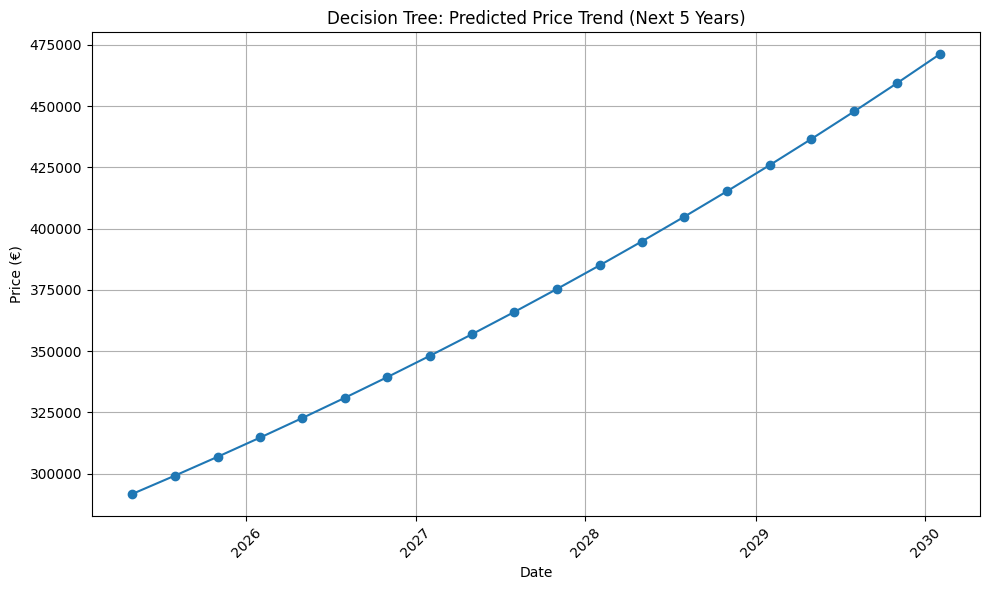

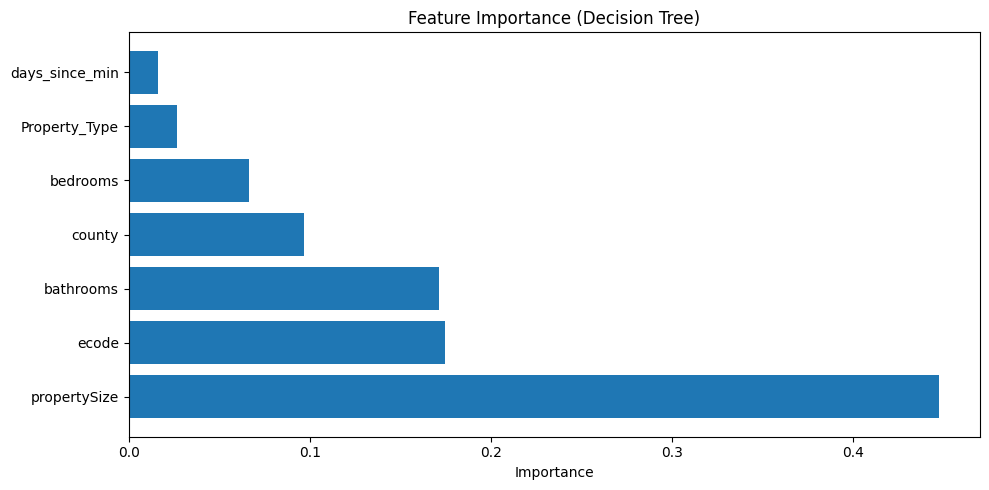

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Log transform prices
df_encoded['log_price'] = np.log1p(df_encoded['price'])

# Create time feature
df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
min_date = df_encoded['publish_date'].min()
df_encoded['days_since_min'] = (df_encoded['publish_date'] - min_date).dt.days

# Calculate time trend from yearly averages
yearly_avg = df_encoded.groupby(df_encoded['publish_date'].dt.year)['log_price'].mean().reset_index()
yearly_avg['year_date'] = pd.to_datetime(yearly_avg['publish_date'].astype(str) + '-01-01')
yearly_avg = yearly_avg.sort_values('year_date')

# Fit linear trend to log prices
from sklearn.linear_model import LinearRegression
days_array = (yearly_avg['year_date'] - min_date).dt.days.values.reshape(-1, 1)
log_trend_model = LinearRegression().fit(days_array, yearly_avg['log_price'].values)
log_price_trend_coef = log_trend_model.coef_[0]

# Calculate annual percentage change
annual_pct_change = (np.exp(log_price_trend_coef * 365) - 1) * 100
print(f"Detected trend: {log_price_trend_coef:.6f} log units/day")
print(f"Annual price change: {annual_pct_change:.2f}%")

# Define features
features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'days_since_min'
]

# Time-based train-test split
df_encoded = df_encoded.sort_values('publish_date')
train_size = 0.8
train_idx = int(len(df_encoded) * train_size)

X_train = df_encoded[features].iloc[:train_idx]
X_test = df_encoded[features].iloc[train_idx:]
y_train = df_encoded['log_price'].iloc[:train_idx]
y_test = df_encoded['log_price'].iloc[train_idx:]

print(f"Training: {df_encoded['publish_date'].iloc[0]} to {df_encoded['publish_date'].iloc[train_idx-1]}")
print(f"Testing: {df_encoded['publish_date'].iloc[train_idx]} to {df_encoded['publish_date'].iloc[-1]}")

# Scale numeric features
num_cols = ['bedrooms', 'bathrooms', 'propertySize', 'days_since_min']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Create decision tree model
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)

# Train model
dt_model.fit(X_train_scaled, y_train)

# Predict test set
y_pred_log = dt_model.predict(X_test_scaled)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

# Calculate metrics
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"\nDecision Tree Results:")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

# Function to predict future prices with trend adjustment
def predict_future_price(future_date, property_features):

    future_date = pd.to_datetime(future_date)
    X_future = pd.DataFrame([property_features])

    # Add time feature
    X_future['days_since_min'] = (future_date - min_date).days

    X_future = X_future[features]
    X_future[num_cols] = scaler.transform(X_future[num_cols])

    # Get base prediction
    base_log_prediction = dt_model.predict(X_future)[0]

    # Apply time trend adjustment
    max_train_date = df_encoded['publish_date'].iloc[train_idx-1]
    days_beyond_training = max(0, (future_date - max_train_date).days)
    log_trend_adjustment = days_beyond_training * log_price_trend_coef

    adjusted_log_prediction = base_log_prediction + log_trend_adjustment
    return np.expm1(adjusted_log_prediction)

# Sample property
sample_property = {
    'bedrooms': 3,
    'bathrooms': 2,
    'propertySize': 100,
    'Property_Type': 2,
    'county': 47,
    'ecode': 56,
}

# Predict future prices
today = pd.Timestamp.now()
future_dates = [
    today,
    today + pd.DateOffset(months=1),
    today + pd.DateOffset(months=2),
    today + pd.DateOffset(months=3),
]

print(f"\nPredictions for sample property:")
for date in future_dates:
    price = predict_future_price(date, sample_property)
    print(f"Date: {date.date()}, Price: €{price:,.2f}")

# Plot price trend
future_dates_5y = pd.date_range(start=today, end=today + pd.DateOffset(years=5), freq='3M')
future_prices = [predict_future_price(date, sample_property) for date in future_dates_5y]

plt.figure(figsize=(10, 6))
plt.plot(future_dates_5y, future_prices, marker='o')
plt.title("Decision Tree: Predicted Price Trend (Next 5 Years)")
plt.xlabel("Date")
plt.ylabel("Price (€)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance['Feature'], importance['Importance'])
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()

plt.show()

Detected trend: 0.000276 log units/day
Annual price change: 10.61%
Training: 2022-12-02 14:57:21 to 2025-02-17 15:44:36
Testing: 2025-02-17 15:45:32 to 2025-03-22 17:13:23

Gradient Boosting Results:
MAE: 87531.53
R²: 0.7170

Predictions for sample property:
Date: 2025-04-23, Price: €229,076.46
Date: 2025-05-23, Price: €230,982.26
Date: 2025-06-23, Price: €232,968.25
Date: 2025-07-23, Price: €234,906.43


<ipython-input-33-05c250ff1fae>:135: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates_5y = pd.date_range(start=today, end=today + pd.DateOffset(years=5), freq='3M')


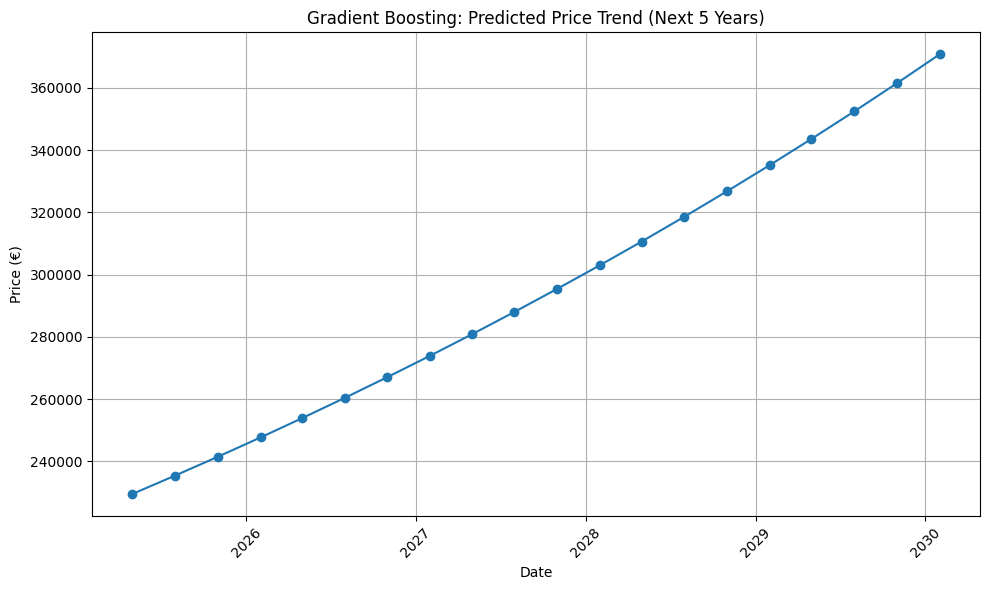

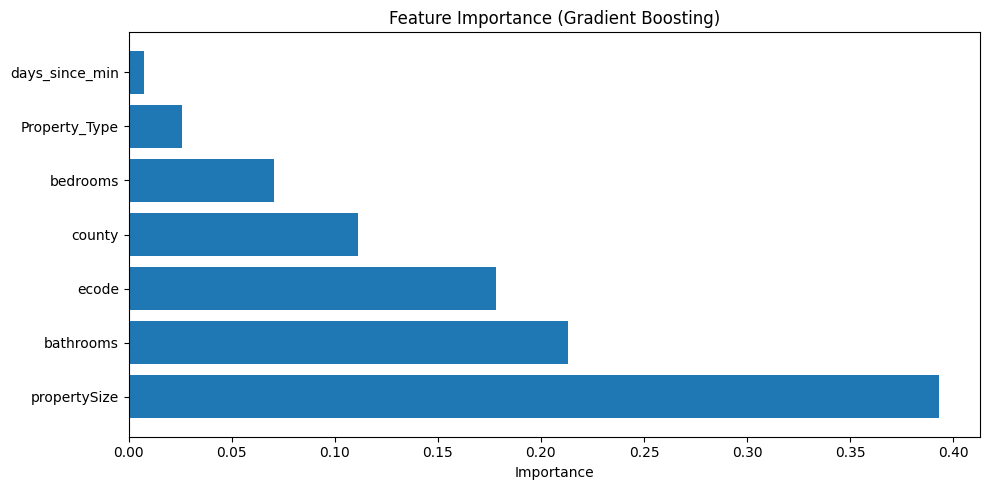

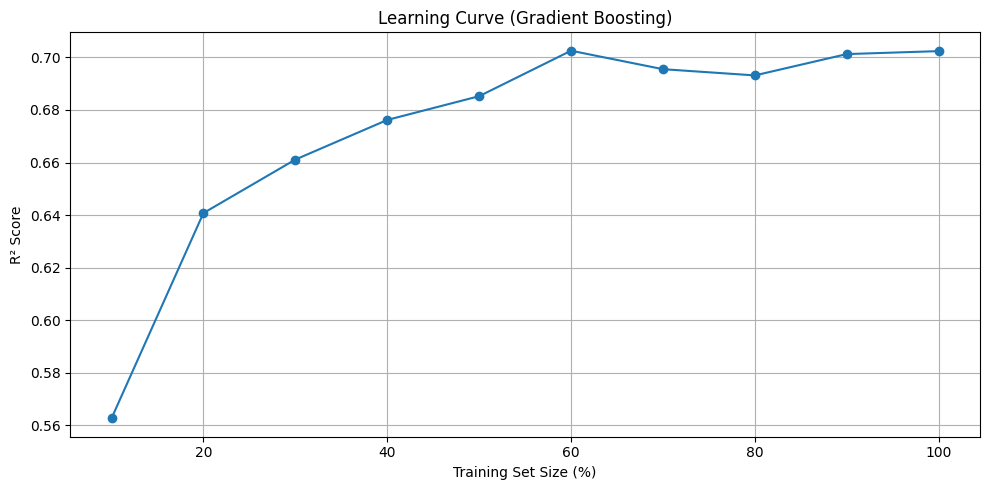

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Log transform prices
df_encoded['log_price'] = np.log1p(df_encoded['price'])

# Create time feature
df_encoded['publish_date'] = pd.to_datetime(df_encoded['publish_date'])
min_date = df_encoded['publish_date'].min()
df_encoded['days_since_min'] = (df_encoded['publish_date'] - min_date).dt.days

# Calculate time trend from yearly averages
yearly_avg = df_encoded.groupby(df_encoded['publish_date'].dt.year)['log_price'].mean().reset_index()
yearly_avg['year_date'] = pd.to_datetime(yearly_avg['publish_date'].astype(str) + '-01-01')
yearly_avg = yearly_avg.sort_values('year_date')

# Fit linear trend to log prices
from sklearn.linear_model import LinearRegression
days_array = (yearly_avg['year_date'] - min_date).dt.days.values.reshape(-1, 1)
log_trend_model = LinearRegression().fit(days_array, yearly_avg['log_price'].values)
log_price_trend_coef = log_trend_model.coef_[0]

# Calculate annual percentage change
annual_pct_change = (np.exp(log_price_trend_coef * 365) - 1) * 100
print(f"Detected trend: {log_price_trend_coef:.6f} log units/day")
print(f"Annual price change: {annual_pct_change:.2f}%")

# Define features
features = [
    'bedrooms', 'bathrooms', 'propertySize',
    'Property_Type', 'county', 'ecode',
    'days_since_min'
]

# Time-based train-test split
df_encoded = df_encoded.sort_values('publish_date')
train_size = 0.8
train_idx = int(len(df_encoded) * train_size)

X_train = df_encoded[features].iloc[:train_idx]
X_test = df_encoded[features].iloc[train_idx:]
y_train = df_encoded['log_price'].iloc[:train_idx]
y_test = df_encoded['log_price'].iloc[train_idx:]

print(f"Training: {df_encoded['publish_date'].iloc[0]} to {df_encoded['publish_date'].iloc[train_idx-1]}")
print(f"Testing: {df_encoded['publish_date'].iloc[train_idx]} to {df_encoded['publish_date'].iloc[-1]}")

# Scale numeric features
num_cols = ['bedrooms', 'bathrooms', 'propertySize', 'days_since_min']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Create gradient boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

# Train model
gb_model.fit(X_train_scaled, y_train)

# Predict test set
y_pred_log = gb_model.predict(X_test_scaled)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

# Calculate metrics
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"\nGradient Boosting Results:")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

# Function to predict future prices with trend adjustment
def predict_future_price(future_date, property_features):

    future_date = pd.to_datetime(future_date)
    X_future = pd.DataFrame([property_features])

    X_future['days_since_min'] = (future_date - min_date).days

    X_future = X_future[features]
    X_future[num_cols] = scaler.transform(X_future[num_cols])

    base_log_prediction = gb_model.predict(X_future)[0]

    max_train_date = df_encoded['publish_date'].iloc[train_idx-1]
    days_beyond_training = max(0, (future_date - max_train_date).days)
    log_trend_adjustment = days_beyond_training * log_price_trend_coef

    adjusted_log_prediction = base_log_prediction + log_trend_adjustment
    return np.expm1(adjusted_log_prediction)

# Sample property
sample_property = {
    'bedrooms': 3,
    'bathrooms': 2,
    'propertySize': 100,
    'Property_Type': 2,
    'county': 47,
    'ecode': 56,
}

# Predict future prices
today = pd.Timestamp.now()
future_dates = [
    today,
    today + pd.DateOffset(months=1),
    today + pd.DateOffset(months=2),
    today + pd.DateOffset(months=3),
]

print(f"\nPredictions for sample property:")
for date in future_dates:
    price = predict_future_price(date, sample_property)
    print(f"Date: {date.date()}, Price: €{price:,.2f}")

# Plot price trend
future_dates_5y = pd.date_range(start=today, end=today + pd.DateOffset(years=5), freq='3M')
future_prices = [predict_future_price(date, sample_property) for date in future_dates_5y]

plt.figure(figsize=(10, 6))
plt.plot(future_dates_5y, future_prices, marker='o')
plt.title("Gradient Boosting: Predicted Price Trend (Next 5 Years)")
plt.xlabel("Date")
plt.ylabel("Price (€)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance['Feature'], importance['Importance'])
plt.title("Feature Importance (Gradient Boosting)")
plt.xlabel("Importance")
plt.tight_layout()

# Learning curves
test_scores = []
train_sizes = np.linspace(0.1, 1.0, 10)
for size in train_sizes:
    size_idx = int(len(X_train) * size)
    X_subset = X_train_scaled.iloc[:size_idx]
    y_subset = y_train.iloc[:size_idx]

    # Train on subset
    subset_model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
    subset_model.fit(X_subset, y_subset)

    # Test score
    score = subset_model.score(X_test_scaled, y_test)
    test_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes * 100, test_scores, marker='o')
plt.title("Learning Curve (Gradient Boosting)")
plt.xlabel("Training Set Size (%)")
plt.ylabel("R² Score")
plt.grid(True)
plt.tight_layout()

plt.show()



**Conclusion: I choose to use RandomForestRegressor to predict property prices because the highest accuracy**